In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from xgboost import XGBRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:\MACHINE LEARNING\TIME SERIES\DATASETS\sales data.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Date')

In [4]:
month_sales = df.groupby(['Date']).agg( Sales = ('Sales', 'sum'), Profit = ('Profit', 'sum'), Quantity = ('Quantity', 'sum')).reset_index()

In [5]:
q1 = month_sales['Sales'].quantile(0.25)
q3 = month_sales['Sales'].quantile(0.75)

iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

month_sales = month_sales[(month_sales['Sales'] < upper) & (month_sales['Sales'] > 0)]

month_sales = month_sales[(month_sales['Profit'] > 0)]


In [6]:
def time(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    df['Dayofyear'] = df['Date'].dt.dayofyear
    df['Quanterr'] = df['Date'].dt.quarter
    return df

def Target_Feature(df):
    df['Lag 1'] = df['Sales'].shift(1)
    df['Target'] = df['Sales'].shift(-1)
    df['Lag 7'] = df['Sales'].shift(7)
    df['Lag 30'] = df['Sales'].shift(30)
    df['MA 7'] = df['Sales'].shift(1).rolling(7).mean()
    df['MA 30'] = df['Sales'].shift(1).rolling(30).mean()
    df['STD 7'] = df['Sales'].shift(1).rolling(7).std()
    df['STD 30'] = df['Sales'].shift(1).rolling(30).std()
    return df

def split(df, test_size = 0.8):
    split = int(len(df) * test_size)
    train, test = df[:split], df[split:]
    return train, test

In [7]:
train, temp = split(month_sales, test_size= 0.8)
val, test = split(month_sales, test_size= 0.5)

In [8]:
train = Target_Feature(train)
train = time(train)
train.dropna(inplace = True)

val = Target_Feature(val)
val = time(val)
val.dropna(inplace = True)

test = Target_Feature(test)
test = time(test)
test.dropna(inplace= True)

In [9]:
del train['Date']
del val['Date']
del test['Date']

In [10]:
x_train = train.drop('Target', axis = 1)
y_train = train['Target']

x_val = val.drop('Target', axis = 1)
y_val = val['Target']

x_test = test.drop('Target', axis = 1)
y_test = test['Target']


In [11]:
selector = SelectKBest(score_func= f_regression, k= 10)

In [12]:
selector = selector.fit(x_train, y_train)

In [13]:
x_train_s = selector.transform(x_train)
x_test_s = selector.transform(x_test)
x_val_s = selector.transform(x_val)

In [14]:
x_transform = PowerTransformer(method= 'box-cox')
y_transform = PowerTransformer(method= 'box-cox')

In [15]:
x_train_sc = x_transform.fit_transform(x_train_s)
x_val_sc = x_transform.transform(x_val_s)
x_test_sc = x_transform.transform(x_test_s)

In [16]:
y_train_sc = y_transform.fit_transform(y_train.to_frame())
y_val_sc = y_transform.transform(y_val.to_frame())
y_test_sc = y_transform.transform(y_test.to_frame())

In [18]:
model = XGBRegressor(n_estimators = 1500, learning_rate = 0.005, max_depth = 5)
model.fit(x_train_sc, y_train_sc)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
pred_train = model.predict(x_train_sc)
pred_val = model.predict(x_val_sc)

In [21]:
pred_train = np.reshape(pred_train, (-1, 1))
pred_val = np.reshape(pred_val, (-1, 1))

In [22]:
pred_train = y_transform.inverse_transform(pred_train)
pred_val = y_transform.inverse_transform(pred_val)

In [26]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)

mae_val = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val)

mae_presistence = mean_absolute_error(y_train, train['MA 30'])
print ("PERSISTENCE ERROR:%.2f"%mae_presistence)

TRAIN ERROR:11847.12
VAL ERROR:10863.33
PERSISTENCE ERROR:30289.64


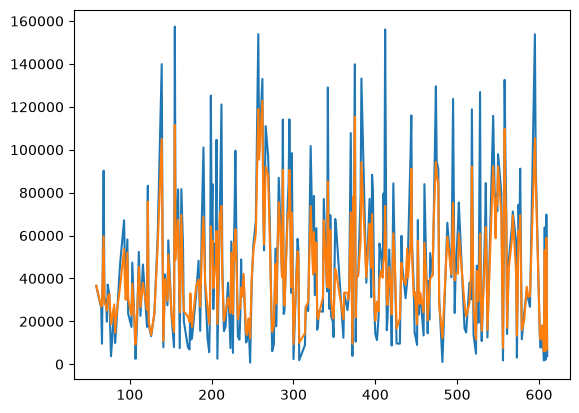

In [31]:
plt.plot(y_val)
plt.plot(y_val.index, pred_val)